In [1]:
%matplotlib qt
# Linear regression


In [2]:
import matplotlib as mpl
import happi
import numpy as np
import matplotlib.pyplot as plt

jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd
jet_vals = jetcmap(np.arange(9)) #extract those values as an array 
jet_vals[0] = [1.0, 1, 1.0, 1] #change the first value 
jet_vals[8] = [0.0, 0, 0.0, 1] #change the first value 
newcmap = mpl.colors.LinearSegmentedColormap.from_list("mine", jet_vals) 

from matplotlib import font_manager

font_dirs = ['/Users/yao/Documents/Calibri and Cambria Fonts/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Calibri'

plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', labelsize=14)
plt.rc('legend', fontsize=12)

/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_14176/4042748947.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jetcmap = plt.cm.get_cmap("jet", 9) #generate a jet map with 10 values "rainbow", "jet", YlOrRd


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# ------------------------------------------------------------
# f(b) = ∫ x e^{-x} / (1 + b e^{-x}) dx
# exact form: f(b) = -Li_2(-b) / b
# ------------------------------------------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if b == 0:
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b


# ------------------------------------------------------------
# Physical parameters
# ------------------------------------------------------------
mu = 1e-7 #1e-8   # radiation-friction parameter (optical laser)

# a0 range chosen to match the figure
a0 = np.linspace(50, 1500, 600)

# compute b and f(b)
b_vals = mu**2 * a0**6
f_vals = np.array([float(f_of_b(b)) for b in b_vals])

# quantity plotted in Fig. 3
y_vals = mu * a0**4 * f_vals


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(a0, y_vals, lw=2)

plt.xlabel(r"$a_0$")
plt.ylabel(r"$\mu a_0^4 f(\mu^2 a_0^6)$")
# plt.title("Fig. 3: Maximum generated magnetic field scaling")

plt.grid(True, ls=":")
plt.tight_layout()
# plt.show()
plt.savefig("fig3_analytic.pdf", dpi=300)

In [14]:
# ------------------------------------------------------------
# Fig.1 μ scan with automatic peak detection
# Marks peak locations and prints numerical a0_peak values
# Saves: fig1_mu_scan_with_peaks.pdf
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# -----------------------------
# Exact f(b) = -Li_2(-b)/b
# -----------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-40"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

# -----------------------------
# Original model curve:
# g(a0) = μ a0^4 f( μ^2 a0^6 )
# -----------------------------
def g_shape(a0, mu):
    b = (mu**2) * (a0**6)
    return float(mu * (a0**4) * f_of_b(b))

# -----------------------------
# Parameters
# -----------------------------
a0_vals = np.linspace(0, 2000, 2000)  # dense grid for accurate peak finding
mu_values = [3e-9, 1e-8, 3e-8]         # example μ values

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7.5, 5))
print("\nPeak locations for each μ:\n")

for mu in mu_values:
    y_vals = np.array([g_shape(a0, mu) for a0 in a0_vals])

    # Peak index and values
    idx_peak = np.argmax(y_vals)
    a0_peak = a0_vals[idx_peak]
    y_peak = y_vals[idx_peak]

    print(f"μ = {mu:.1e}  -->  a0_peak ≈ {a0_peak:.1f}")

    # Plot the curve
    plt.plot(a0_vals, y_vals, lw=2, label=rf"$\mu={mu:.0e}$")

    # Mark and label the peak
    plt.plot(a0_peak, y_peak, "o")
    plt.text(a0_peak, y_peak, f"  {a0_peak:.0f}",
             va="bottom", ha="left", fontsize=10)

plt.xlabel(r"$a_0$", fontsize=13)
plt.ylabel(r"$\mu a_0^4 f(\mu^2 a_0^6)$", fontsize=13)
plt.title(r"Turnover position vs $\mu$ (original model)", fontsize=13)
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig("/Users/yao/Desktop/fig1_mu_scan_with_peaks.pdf")
plt.show()


Peak locations for each μ:

μ = 3.0e-09  -->  a0_peak ≈ 1704.9
μ = 1.0e-08  -->  a0_peak ≈ 1141.6
μ = 3.0e-08  -->  a0_peak ≈ 791.4


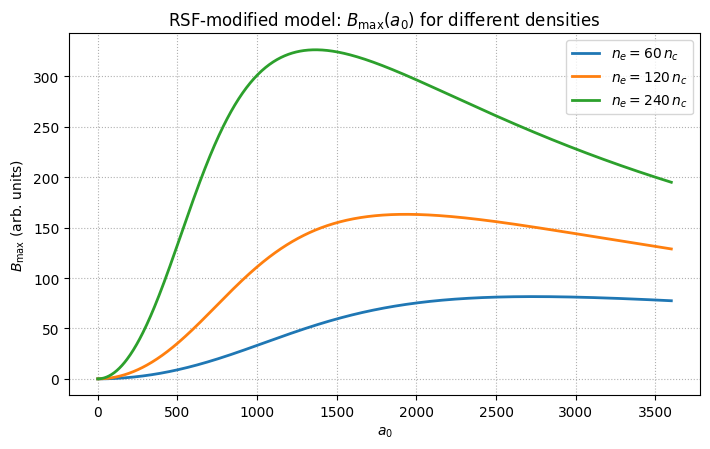

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# ------------------------------------------------------------
# Exact f(b): f(b) = ∫_0^∞ x e^{-x} / (1 + b e^{-x}) dx = -Li_2(-b)/b
# ------------------------------------------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-30"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

# ------------------------------------------------------------
# RSF-modified analytic scaling (arb units):
# Bmax ∝ μ (ne/nc)^2 a0^2 f( μ^2 a0^4 (ne/nc)^2 )
# ------------------------------------------------------------
def B_shape(a0, ne_over_nc, mu):
    b = (mu**2) * (a0**4) * (ne_over_nc**2)
    f = float(f_of_b(b))
    return mu * (ne_over_nc**2) * (a0**2) * f

# Parameters
mu = 1e-8
densities = [60, 120, 240]  # in units of nc

# a0 range (linear, paper-style)
a0_vals = np.linspace(0.0, 3600.0, 900)

# Plot
plt.figure(figsize=(7.2, 4.6))
for ne_over_nc in densities:
    y = np.array([B_shape(a0, ne_over_nc, mu) for a0 in a0_vals])
    plt.plot(a0_vals, y, lw=2, label=rf"$n_e={ne_over_nc}\,n_c$")

plt.xlabel(r"$a_0$")
plt.ylabel(r"$B_{\max}$ (arb. units)")
plt.title(r"RSF-modified model: $B_{\max}(a_0)$ for different densities")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig("/Users/yao/Desktop/analytic_RSF.pdf", dpi=300)

In [5]:
# calibration

# Physical constants (SI)
m_e = 9.1093837015e-31
c   = 299792458.0
e   = 1.602176634e-19

def prefactor_P(T_fs, w0_um):
    """
    Returns P = (m_e c^2 / e) * (T / w0^2) in Tesla per (dimensionless shape unit).
    """
    T = T_fs * 1e-15
    w0 = w0_um * 1e-6
    return (m_e * c**2 / e) * (T / w0**2)

def calibrate_C_order1(a0_cal, ne_over_nc_cal, B_pic_cal_T,
                       mu=1e-8, T_fs=20.0, w0_um=4.0):
    """
    Returns dimensionless C such that:
    B_Tesla ≈ C * P(T,w0) * B_shape(a0, ne/nc, mu)
    """
    P = prefactor_P(T_fs, w0_um)
    B_model = P * B_shape(a0_cal, ne_over_nc_cal, mu)
    return B_pic_cal_T / B_model

In [ ]:
C = calibrate_C_order1(a0_cal=500, ne_over_nc_cal=120, B_pic_cal_T=2.0e5,
                       mu=1e-8, T_fs=20.0, w0_um=4.0)

P = prefactor_P(T_fs=20.0, w0_um=4.0)
B_pred_T = C * P * np.array([B_shape(a0, 120, 1e-8) for a0 in a0_vals])


In [7]:
# Plot
plt.figure(figsize=(7.2, 4.6))
for ne_over_nc in densities:
    y = np.array([B_shape(a0, ne_over_nc, mu) for a0 in a0_vals])
    plt.plot(a0_vals, y, lw=2, label=rf"$n_e={ne_over_nc}\,n_c$")
    plt.plot(a0_vals, B_pred_T, lw=2, ls="--", label=rf"Calibrated $n_e=120\,n_c$")

plt.xlabel(r"$a_0$")
plt.ylabel(r"$B_{\max}$ (arb. units)")
plt.title(r"RSF-modified model: $B_{\max}(a_0)$ for different densities")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

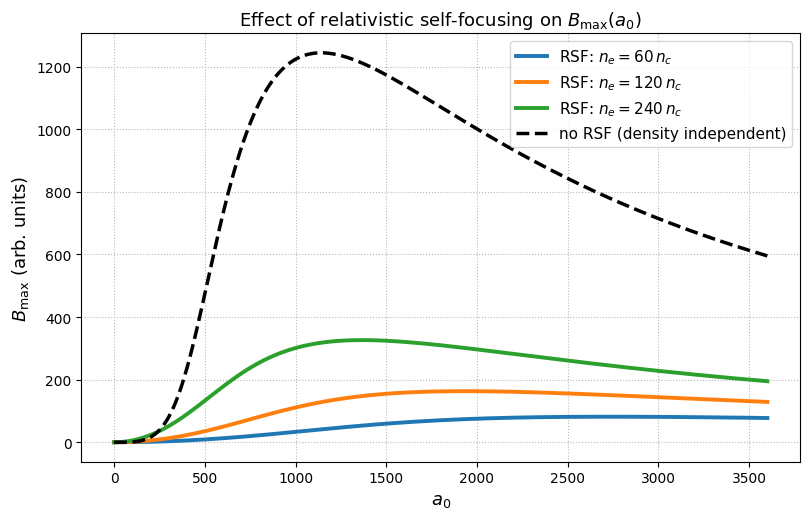

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# ------------------------------------------------------------
# Exact f(b) = -Li_2(-b)/b
# ------------------------------------------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-40"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

# ------------------------------------------------------------
# No-RSF (original) scaling:
# B_noRSF ∝ μ a0^4 f( μ^2 a0^6 )
# ------------------------------------------------------------
def B_noRSF(a0, mu):
    b = (mu**2) * (a0**6)
    return float(mu * (a0**4) * f_of_b(b))

# ------------------------------------------------------------
# RSF-modified scaling:
# B_RSF ∝ μ (ne/nc)^2 a0^2 f( μ^2 a0^4 (ne/nc)^2 )
# ------------------------------------------------------------
def B_RSF(a0, ne_over_nc, mu):
    b = (mu**2) * (a0**4) * (ne_over_nc**2)
    return float(mu * (ne_over_nc**2) * (a0**2) * f_of_b(b))

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
mu = 1e-8
densities = [60, 120, 240]
a0_vals = np.linspace(0.0, 3600.0, 1400)

# Compute curves
noRSF_vals = np.array([B_noRSF(a0, mu) for a0 in a0_vals])

plt.figure(figsize=(8.2, 5.3))

# RSF curves (solid)
for ne_over_nc in densities:
    y_rsf = np.array([B_RSF(a0, ne_over_nc, mu) for a0 in a0_vals])
    plt.plot(a0_vals, y_rsf, lw=2.8,
             label=rf"RSF: $n_e={ne_over_nc}\,n_c$")

# Single no-RSF baseline (dashed, black)
plt.plot(a0_vals, noRSF_vals,
         lw=2.5, ls="--", color="black",
         label="no RSF (density independent)")

plt.title(r"Effect of relativistic self-focusing on $B_{\max}(a_0)$",
          fontsize=13)
plt.xlabel(r"$a_0$", fontsize=13)
plt.ylabel(r"$B_{\max}$ (arb. units)", fontsize=13)

plt.grid(True, ls=":", alpha=0.9)
plt.legend(fontsize=11)
plt.tight_layout()

# plt.savefig("Bmax_RSF_vs_noRSF.pdf")
# plt.savefig("Bmax_RSF_vs_noRSF.png", dpi=300)
plt.show()

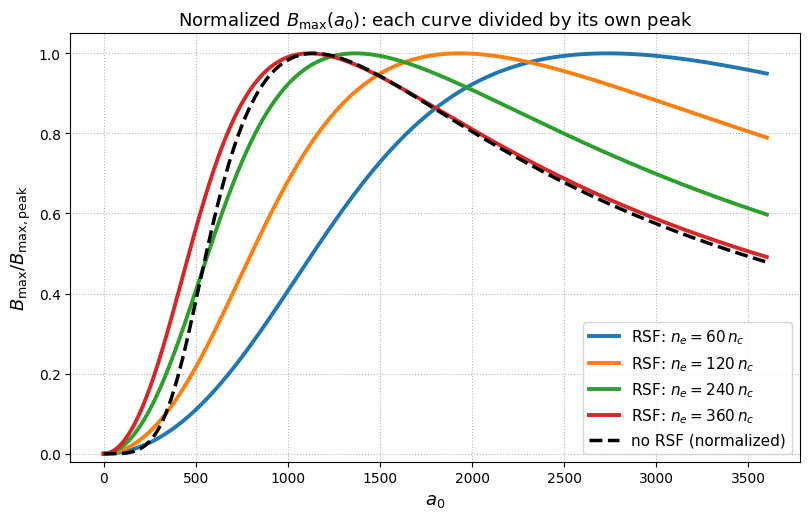

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# ------------------------------------------------------------
# Exact f(b) = -Li_2(-b)/b
# ------------------------------------------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-40"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

# ------------------------------------------------------------
# No-RSF (original) scaling:
# B_noRSF ∝ μ a0^4 f( μ^2 a0^6 )
# ------------------------------------------------------------
def B_noRSF(a0, mu):
    b = (mu**2) * (a0**6)
    return float(mu * (a0**4) * f_of_b(b))

# ------------------------------------------------------------
# RSF-modified scaling:
# B_RSF ∝ μ (ne/nc)^2 a0^2 f( μ^2 a0^4 (ne/nc)^2 )
# ------------------------------------------------------------
def B_RSF(a0, ne_over_nc, mu):
    b = (mu**2) * (a0**4) * (ne_over_nc**2)
    return float(mu * (ne_over_nc**2) * (a0**2) * f_of_b(b))

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
mu = 1e-8
densities = [60, 120, 240, 360]
a0_vals = np.linspace(0.0, 3600.0, 1400)

plt.figure(figsize=(8.2, 5.3))

# RSF curves (solid), normalized to their own maxima
for ne_over_nc in densities:
    y = np.array([B_RSF(a0, ne_over_nc, mu) for a0 in a0_vals])
    y_max = np.max(y)
    y_norm = y / y_max if y_max > 0 else y
    plt.plot(a0_vals, y_norm, lw=2.8,
             label=rf"RSF: $n_e={ne_over_nc}\,n_c$")

# No-RSF baseline (dashed), normalized to its own maximum
y0 = np.array([B_noRSF(a0, mu) for a0 in a0_vals])
y0_max = np.max(y0)
y0_norm = y0 / y0_max if y0_max > 0 else y0

plt.plot(a0_vals, y0_norm, lw=2.5, ls="--", color="black",
         label="no RSF (normalized)")

plt.title(r"Normalized $B_{\max}(a_0)$: each curve divided by its own peak",
          fontsize=13)
plt.xlabel(r"$a_0$", fontsize=13)
plt.ylabel(r"$B_{\max}/B_{\max,\mathrm{peak}}$", fontsize=13)

plt.ylim(-0.02, 1.05)
plt.grid(True, ls=":", alpha=0.9)
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig("Bmax_RSF_vs_noRSF_normalized.pdf")
plt.savefig("Bmax_RSF_vs_noRSF_normalized.png", dpi=300)
plt.show()


Fit results for ne=120 nc, a0 in [300, 1000]:

Power-law:   B ≈ A * a0^p
   A = 3.407385e-04,   p = 1.851743



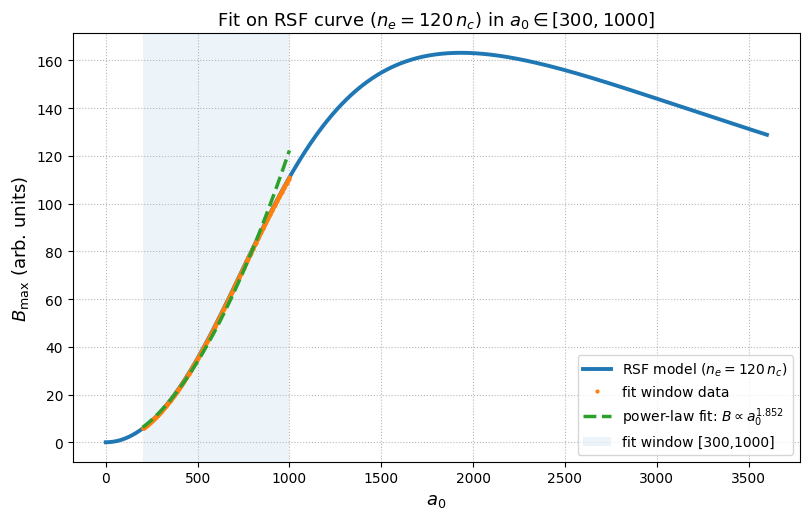

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# -----------------------------
# Exact f(b) = -Li_2(-b)/b
# -----------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-40"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

# -----------------------------
# RSF-modified scaling (arb units)
# B_RSF ∝ μ (ne/nc)^2 a0^2 f( μ^2 a0^4 (ne/nc)^2 )
# -----------------------------
def B_RSF(a0, ne_over_nc, mu):
    b = (mu**2) * (a0**4) * (ne_over_nc**2)
    return float(mu * (ne_over_nc**2) * (a0**2) * f_of_b(b))

# -----------------------------
# Settings
# -----------------------------
mu = 1e-8
ne_over_nc = 120

a0_all = np.linspace(0.0, 3600.0, 1600)
B_all = np.array([B_RSF(a0, ne_over_nc, mu) for a0 in a0_all])

# Fit window
a0_min, a0_max = 200.0, 1000.0
mask = (a0_all >= a0_min) & (a0_all <= a0_max)
a0_fit = a0_all[mask]
B_fit = B_all[mask]

# Safety: ensure positive values for log fits
eps = 1e-300
B_fit_pos = np.maximum(B_fit, eps)

# ============================================================
# 1) Power-law fit: B ≈ A * a0^p  => log(B)=log(A)+p log(a0)
# ============================================================
logx = np.log(a0_fit)
logy = np.log(B_fit_pos)

p, logA = np.polyfit(logx, logy, 1)   # slope p, intercept logA
A = np.exp(logA)

B_power = A * (a0_fit**p)

# # ============================================================
# # 2) Exponential fit: B ≈ Aexp * exp(k a0) => log(B)=log(Aexp)+k a0
# # ============================================================
# k, logAexp = np.polyfit(a0_fit, np.log(B_fit_pos), 1)
# Aexp = np.exp(logAexp)

# B_exp = Aexp * np.exp(k * a0_fit)

# -----------------------------
# Print fit results
# -----------------------------
print("\nFit results for ne=120 nc, a0 in [300, 1000]:\n")
print(f"Power-law:   B ≈ A * a0^p")
print(f"   A = {A:.6e},   p = {p:.6f}\n")
# print(f"Exponential: B ≈ Aexp * exp(k a0)")
# print(f"   Aexp = {Aexp:.6e},   k = {k:.6e} (per unit a0)\n")

# -----------------------------
# Plot overlay
# -----------------------------
plt.figure(figsize=(8.2, 5.3))

# Full analytic RSF curve for ne=120
plt.plot(a0_all, B_all, lw=2.8, label=r"RSF model ($n_e=120\,n_c$)")

# Overlay fit window data (optional highlight)
plt.plot(a0_fit, B_fit, lw=0, marker=".", markersize=4, label="fit window data")

# Fitted curves in the fit window
plt.plot(a0_fit, B_power, lw=2.5, ls="--",
         label=rf"power-law fit: $B\propto a_0^{{{p:.3f}}}$")

# plt.plot(a0_fit, B_exp, lw=2.5, ls=":",
#          label=rf"exp fit: $B\propto e^{{({k:.2e})a_0}}$")

plt.axvspan(a0_min, a0_max, alpha=0.08, label="fit window [300,1000]")

plt.xlabel(r"$a_0$", fontsize=13)
plt.ylabel(r"$B_{\max}$ (arb. units)", fontsize=13)
plt.title(r"Fit on RSF curve ($n_e=120\,n_c$) in $a_0\in[300,1000]$", fontsize=13)
plt.grid(True, ls=":", alpha=0.9)
plt.legend(fontsize=10)
plt.tight_layout()

plt.savefig("Bmax_RSF_ne120_fit_300_1000.pdf")
plt.savefig("Bmax_RSF_ne120_fit_300_1000.png", dpi=300)
plt.show()